In [283]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [284]:
df=sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Feature Eng.

In [285]:
df['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [286]:
df['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [287]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [288]:
df['time'].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [289]:
from sklearn.preprocessing import OneHotEncoder

In [290]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [291]:
X=df.drop('time',axis=1)
y=df['time']

In [292]:
y=y.map({'Dinner':1,'Lunch':0})

In [293]:
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first'), ['sex','smoker','day'])
    ],
    remainder='passthrough'
)

X_transformed = ct.fit_transform(X)

In [294]:
X_transformed

array([[ 0.  ,  0.  ,  0.  , ..., 16.99,  1.01,  2.  ],
       [ 1.  ,  0.  ,  0.  , ..., 10.34,  1.66,  3.  ],
       [ 1.  ,  0.  ,  0.  , ..., 21.01,  3.5 ,  3.  ],
       ...,
       [ 1.  ,  1.  ,  1.  , ..., 22.67,  2.  ,  2.  ],
       [ 1.  ,  0.  ,  1.  , ..., 17.82,  1.75,  2.  ],
       [ 0.  ,  0.  ,  0.  , ..., 18.78,  3.  ,  2.  ]], shape=(244, 8))

In [295]:
y

0      1
1      1
2      1
3      1
4      1
      ..
239    1
240    1
241    1
242    1
243    1
Name: time, Length: 244, dtype: category
Categories (2, int64): [0, 1]

In [296]:
y.value_counts()

time
1    176
0     68
Name: count, dtype: int64

In [297]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_transformed,y,test_size=0.20,random_state=42)

In [298]:
from sklearn.naive_bayes import GaussianNB

In [299]:
gnb=GaussianNB()

In [300]:
gnb.fit(X_train,y_train)

GaussianNB()

In [301]:
y_pred=gnb.predict(X_test)

In [302]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

ACCURACY: 95.91836734693877 %
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        15
           1       1.00      0.94      0.97        34

    accuracy                           0.96        49
   macro avg       0.94      0.97      0.95        49
weighted avg       0.96      0.96      0.96        49



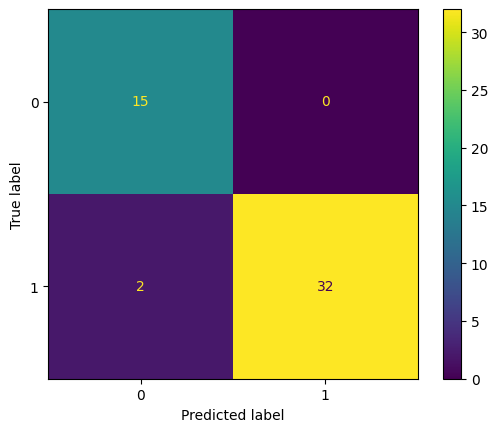

In [304]:
print("ACCURACY:",accuracy_score(y_test,y_pred)*100,"%")
print(classification_report(y_test,y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred))
disp.plot()